In [10]:
import bigframes
import bigframes.pandas as bpd
import statsmodels.api as sm
import pandas as pd
import numpy as np
import patsy
import matplotlib.pyplot as plt

# Connect to your GCP project (uses Application Default Credentials)
bigframes.options.bigquery.project = "belayground-467323"
bigframes.options.bigquery.location = "us-south1"

%load_ext bigframes

The bigframes extension is already loaded. To reload it, use:
  %reload_ext bigframes


In [11]:
%%bqsql df_player_series
with player_series_base as (
    select
        person_id,
        first_name,
        last_name,
        safe_cast(year_id as int64) as year_id,
        series_id,
        player_team_id,
        opponent_team_id,

        series_start_date,
        series_end_date,
        player_series_games_played,

        series_minutes,
        series_points,
        series_assists,
        series_rebounds_total,
        series_blocks,
        series_steals,
        series_field_goals_attempted,
        series_field_goals_made,
        series_field_goals_percentage,
        series_turnovers,

        actual_win,
        expected_win_prob,
        expected_money_line,
        series_residual,
        series_sum_game_residual,
        avg_player_game_forecast,

        ln(
            safe_divide(
                expected_win_prob,
                1 - expected_win_prob
            )
        ) as expected_logit

    from `belayground-467323.nba_staging_custom.elo_series_mapping`
    where person_id is not null
        and series_id is not null
        and player_team_id is not null
        and opponent_team_id is not null

        and actual_win is not null
        and actual_win in (0, 1)

        and expected_win_prob is not null
        and expected_win_prob > 0
        and expected_win_prob < 1

        and series_minutes is not null
        and series_minutes > 0
),

career_filters as (
    select
        person_id,
        count(distinct series_id) as career_playoff_series,
        sum(series_minutes) as career_playoff_minutes,
        sum(series_points) as career_playoff_points,
        sum(series_assists) as career_playoff_assists,
        sum(series_rebounds_total) as career_playoff_rebounds_total
    from player_series_base
    group by
        person_id
    having career_playoff_series > 10
        and career_playoff_minutes > 4000
)

select
    player_series_base.*,

    career_filters.career_playoff_series,
    career_filters.career_playoff_minutes,
    career_filters.career_playoff_points,
    career_filters.career_playoff_assists,
    career_filters.career_playoff_rebounds_total,

    safe_divide(series_points, series_minutes) * 36 as series_points_per_36,
    safe_divide(series_assists, series_minutes) * 36 as series_assists_per_36,
    safe_divide(series_rebounds_total, series_minutes) * 36 as series_rebounds_per_36,
    safe_divide(series_blocks, series_minutes) * 36 as series_blocks_per_36,
    safe_divide(series_steals, series_minutes) * 36 as series_steals_per_36,
    safe_divide(series_turnovers, series_minutes) * 36 as series_turnovers_per_36

from player_series_base
inner join career_filters
    on player_series_base.person_id = career_filters.person_id
order by
    player_series_base.person_id,
    player_series_base.series_start_date,
    player_series_base.series_id

,person_id,first_name,last_name,year_id,series_id,player_team_id,opponent_team_id,series_start_date,series_end_date,player_series_games_played,...,career_playoff_minutes,career_playoff_points,career_playoff_assists,career_playoff_rebounds_total,series_points_per_36,series_assists_per_36,series_rebounds_per_36,series_blocks_per_36,series_steals_per_36,series_turnovers_per_36
0,2,Byron,Scott,1984,1984westfirstround16106127471610612758,1610612747,1610612758,1984-04-20,1984-04-22,2,...,5360.0,2451,392,536,2.4,8.4,2.4,0.0,2.4,4.8
1,2,Byron,Scott,1984,1984westconfsemifinals16106127421610612747,1610612747,1610612742,1984-04-28,1984-05-08,5,...,5360.0,2451,392,536,15.476636,4.71028,4.037383,0.336449,1.009346,2.018692
2,2,Byron,Scott,1984,1984westconffinals16106127471610612756,1610612747,1610612756,1984-05-12,1984-05-25,6,...,5360.0,2451,392,536,18.0,1.777778,3.333333,0.222222,1.333333,2.222222
3,2,Byron,Scott,1984,1984nbafinals16106127381610612747,1610612747,1610612738,1984-05-27,1984-06-12,7,...,5360.0,2451,392,536,14.4,1.714286,2.742857,0.0,2.4,2.057143
4,2,Byron,Scott,1985,1985westfirstround16106127471610612756,1610612747,1610612756,1985-04-18,1985-04-23,3,...,5360.0,2451,392,536,20.571429,4.207792,4.675325,0.467532,4.207792,1.87013
5,2,Byron,Scott,1985,1985westconfsemifinals16106127471610612757,1610612747,1610612757,1985-04-27,1985-05-07,5,...,5360.0,2451,392,536,21.74026,3.038961,2.103896,0.233766,1.87013,1.168831
6,2,Byron,Scott,1985,1985westconffinals16106127431610612747,1610612747,1610612743,1985-05-11,1985-05-22,5,...,5360.0,2451,392,536,28.849315,3.69863,2.712329,0.246575,2.219178,1.726027
7,2,Byron,Scott,1985,1985nbafinals16106127381610612747,1610612747,1610612738,1985-05-27,1985-06-09,6,...,5360.0,2451,392,536,11.596154,2.25,3.807692,0.173077,2.596154,1.384615
8,2,Byron,Scott,1986,1986westfirstround16106127471610612759,1610612747,1610612759,1986-04-17,1986-04-23,3,...,5360.0,2451,392,536,24.0,3.111111,4.0,0.0,2.666667,3.111111
9,2,Byron,Scott,1986,1986westconfsemifinals16106127421610612747,1610612747,1610612742,1986-04-27,1986-05-08,6,...,5360.0,2451,392,536,17.828571,2.914286,4.457143,0.171429,1.028571,1.714286


In [12]:
df_player_series.peek(5)
df = df_player_series.to_pandas()
df.head(5)

,person_id,first_name,last_name,year_id,series_id,player_team_id,opponent_team_id,series_start_date,series_end_date,player_series_games_played,...,career_playoff_minutes,career_playoff_points,career_playoff_assists,career_playoff_rebounds_total,series_points_per_36,series_assists_per_36,series_rebounds_per_36,series_blocks_per_36,series_steals_per_36,series_turnovers_per_36
0,2,Byron,Scott,1984,1984westfirstround16106127471610612758,1610612747,1610612758,1984-04-20,1984-04-22,2,...,5360.0,2451,392,536,2.4,8.4,2.4,0.0,2.4,4.8
1,2,Byron,Scott,1984,1984westconfsemifinals16106127421610612747,1610612747,1610612742,1984-04-28,1984-05-08,5,...,5360.0,2451,392,536,15.476636,4.71028,4.037383,0.336449,1.009346,2.018692
2,2,Byron,Scott,1984,1984westconffinals16106127471610612756,1610612747,1610612756,1984-05-12,1984-05-25,6,...,5360.0,2451,392,536,18.0,1.777778,3.333333,0.222222,1.333333,2.222222
3,2,Byron,Scott,1984,1984nbafinals16106127381610612747,1610612747,1610612738,1984-05-27,1984-06-12,7,...,5360.0,2451,392,536,14.4,1.714286,2.742857,0.0,2.4,2.057143
4,2,Byron,Scott,1985,1985westfirstround16106127471610612756,1610612747,1610612756,1985-04-18,1985-04-23,3,...,5360.0,2451,392,536,20.571429,4.207792,4.675325,0.467532,4.207792,1.87013


In [13]:
required_cols = [
    "person_id",
    "first_name",
    "last_name",
    "actual_win",
    "expected_win_prob",
    "expected_logit",
    "series_minutes",
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"missing required columns: {missing_cols}")

df = df.dropna(subset=required_cols).copy()

df["person_id"] = df["person_id"].astype(str)
df["actual_win"] = pd.to_numeric(df["actual_win"], errors="coerce").astype(int)
df["expected_win_prob"] = pd.to_numeric(df["expected_win_prob"], errors="coerce")
df["expected_logit"] = pd.to_numeric(df["expected_logit"], errors="coerce")
df["series_minutes"] = pd.to_numeric(df["series_minutes"], errors="coerce")

df = df[
    (df["actual_win"].isin([0, 1]))
    & (df["expected_win_prob"] > 0)
    & (df["expected_win_prob"] < 1)
    & (df["series_minutes"] > 0)
].copy()

# Scale weights so minutes do not create extreme frequency-weight behavior.
# This keeps player involvement as a weight without treating 240 minutes as 240 repeated rows.
df["weight"] = df["series_minutes"] / 36

y, X = patsy.dmatrices(
    "actual_win ~ 0 + C(person_id)",
    data=df,
    return_type="dataframe",
)

model = sm.GLM(
    y,
    X,
    family=sm.families.Binomial(),
    offset=df["expected_logit"],
    var_weights=df["weight"],
)

result = model.fit()

coef_table = result.summary2().tables[1].reset_index()

coef_table = coef_table.rename(
    columns={
        "index": "player_term",
        "Coef.": "log_odds_over_expected",
        "Std.Err.": "std_error",
        "P>|z|": "p_value",
        "[0.025": "ci_lower",
        "0.975]": "ci_upper",
    }
)

coef_table["person_id"] = (
    coef_table["player_term"]
    .str.extract(r"C\(person_id\)\[(.*)\]")
)

coef_table["odds_multiplier_over_expected"] = np.exp(
    coef_table["log_odds_over_expected"]
)

coef_table["odds_multiplier_ci_lower"] = np.exp(coef_table["ci_lower"])
coef_table["odds_multiplier_ci_upper"] = np.exp(coef_table["ci_upper"])

player_names = (
    df[["person_id", "first_name", "last_name"]]
    .drop_duplicates()
)

player_effects = coef_table.merge(
    player_names,
    on="person_id",
    how="left",
)

player_effects["player_name"] = (
    player_effects["first_name"] + " " + player_effects["last_name"]
)

player_effects = player_effects.sort_values(
    "log_odds_over_expected",
    ascending=False,
)

## player-series timeline dataframe

In [14]:
plot_df = df.copy()

plot_df["person_id"] = plot_df["person_id"].astype(str)

plot_df["player_name"] = (
    plot_df["first_name"].fillna("")
    + " "
    + plot_df["last_name"].fillna("")
).str.strip()

plot_df["series_start_date"] = pd.to_datetime(plot_df["series_start_date"])

plot_df = plot_df.sort_values(
    ["person_id", "series_start_date", "series_id"]
).copy()

plot_df["player_series_number"] = (
    plot_df
    .groupby("person_id")
    .cumcount()
    + 1
)

plot_df["career_cumulative_series_residual"] = (
    plot_df
    .groupby("person_id")["series_residual"]
    .cumsum()
)

In [15]:
### only plottin' the top 15 players for now, change this cell for boarder players

top_players = (
    plot_df
    .groupby(["person_id", "player_name"], as_index=False)
    .agg(
        final_cumulative_residual=("career_cumulative_series_residual", "last"),
        career_playoff_series=("series_id", "nunique"),
        career_playoff_minutes=("series_minutes", "sum")
    )
    .sort_values("final_cumulative_residual", ascending=False)
    .head(20)
)

plot_top = plot_df.merge(
    top_players[["person_id"]],
    on="person_id",
    how="inner"
)

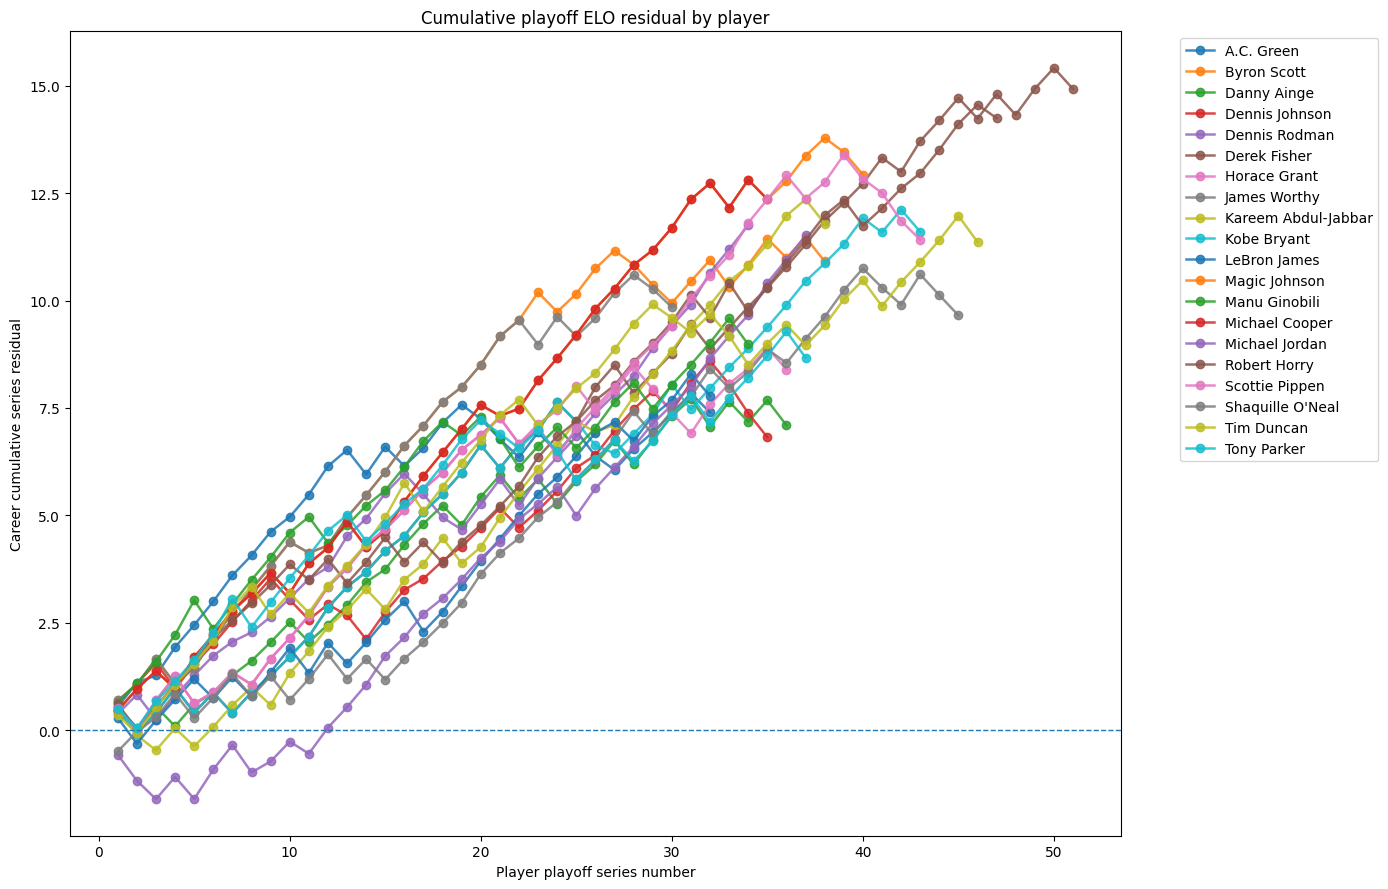

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 9))

for player_name, player_data in plot_top.groupby("player_name"):
    player_data = player_data.sort_values("player_series_number")

    plt.plot(
        player_data["player_series_number"],
        player_data["career_cumulative_series_residual"],
        marker="o",
        linewidth=1.8,
        alpha=0.85,
        label=player_name
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Player playoff series number")
plt.ylabel("Career cumulative series residual")
plt.title("Cumulative playoff ELO residual by player")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()